✅ Данные успешно загружены!
Размер: (307511, 122)
Колонки: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...

🎯 Распределение TARGET:
TARGET
0    282686
1     24825
Name: count, dtype: int64


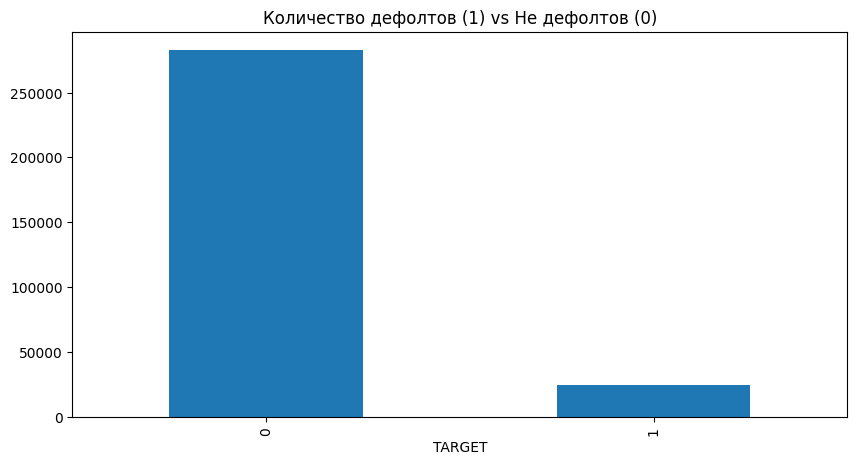

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    train = pd.read_csv('../data/raw/application_train.csv')
    print("✅ Данные успешно загружены!")
    print(f"Размер: {train.shape}")
    print(f"Колонки: {train.columns.tolist()[:10]}...")
    
    # Целевая переменная
    print("\n🎯 Распределение TARGET:")
    print(train['TARGET'].value_counts())
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    train['TARGET'].value_counts().plot(kind='bar')
    plt.title('Количество дефолтов (1) vs Не дефолтов (0)')
    plt.show()
    
except Exception as e:
    print(f"❌ Ошибка: {e}")
    print("Проверь путь к файлу!")

In [2]:
!pip install pandas numpy matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.8 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.7 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.7 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.7 MB 2.9 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.7 MB 3.1 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.7 MB 3.3 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.7 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.

In [4]:
print("\n🔍 БАЗОВЫЙ АНАЛИЗ ДАННЫХ:")
print("=" * 50)

# 1. Типы данных
print("\n📝 ТИПЫ ДАННЫХ:")
print(train.dtypes.value_counts())

# 2. Пропущенные значения
print("\n⚠️  ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (ТОП-20):")
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)
print(missing_df.head(20))

# 3. Память данных
print(f"\n💾 ИСПОЛЬЗОВАНИЕ ПАМЯТИ: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


🔍 БАЗОВЫЙ АНАЛИЗ ДАННЫХ:

📝 ТИПЫ ДАННЫХ:
float64    65
int64      41
str        16
Name: count, dtype: int64

⚠️  ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (ТОП-20):
                          missing_count  missing_percent
COMMONAREA_MEDI                  214865        69.872297
COMMONAREA_MODE                  214865        69.872297
COMMONAREA_AVG                   214865        69.872297
NONLIVINGAPARTMENTS_MODE         213514        69.432963
NONLIVINGAPARTMENTS_MEDI         213514        69.432963
NONLIVINGAPARTMENTS_AVG          213514        69.432963
FONDKAPREMONT_MODE               210295        68.386172
LIVINGAPARTMENTS_AVG             210199        68.354953
LIVINGAPARTMENTS_MEDI            210199        68.354953
LIVINGAPARTMENTS_MODE            210199        68.354953
FLOORSMIN_MEDI                   208642        67.848630
FLOORSMIN_MODE                   208642        67.848630
FLOORSMIN_AVG                    208642        67.848630
YEARS_BUILD_MODE                 204488        66.497784


📊 ВИЗУАЛИЗАЦИИ:


C:\Users\Админ\AppData\Local\Temp\ipykernel_9524\321341995.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['AGE'] = -train['DAYS_BIRTH'] / 365.25


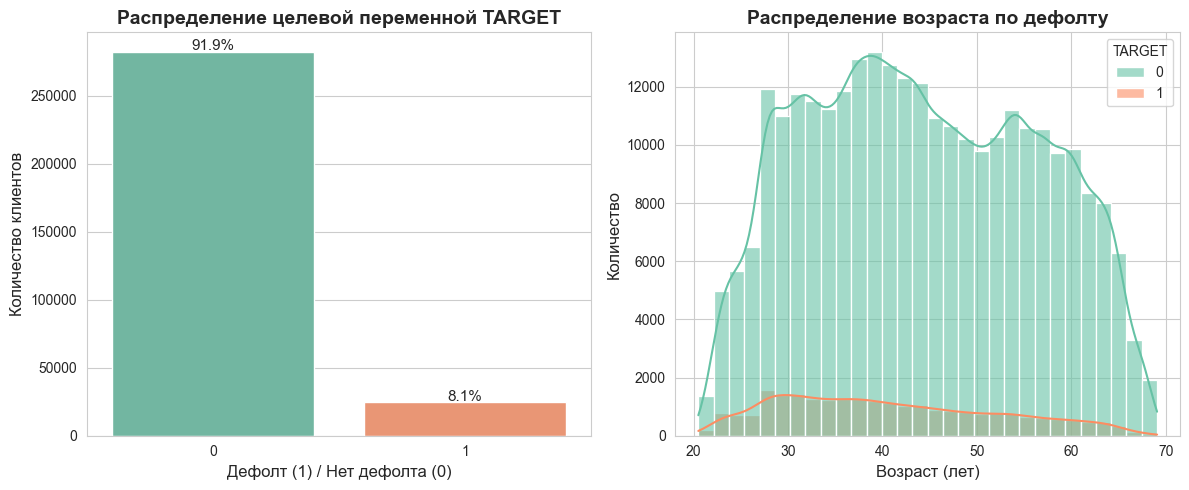

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

print("\n📊 ВИЗУАЛИЗАЦИИ:")
print("=" * 50)

# 1. Распределение целевой переменной (уже есть, но сделаем красивей)
plt.figure(figsize=(12, 5))

# График 1: Количество
plt.subplot(1, 2, 1)
ax = sns.countplot(x='TARGET', data=train, palette='Set2', hue='TARGET', legend=False)
plt.title('Распределение целевой переменной TARGET', fontsize=14, fontweight='bold')
plt.xlabel('Дефолт (1) / Нет дефолта (0)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

# Добавляем проценты
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), ha='center', fontsize=11)

# График 2: Возраст клиентов
plt.subplot(1, 2, 2)
if 'DAYS_BIRTH' in train.columns:
    train['AGE'] = -train['DAYS_BIRTH'] / 365.25
    sns.histplot(data=train, x='AGE', hue='TARGET', bins=30, kde=True, palette='Set2', alpha=0.6)
    plt.title('Распределение возраста по дефолту', fontsize=14, fontweight='bold')
    plt.xlabel('Возраст (лет)', fontsize=12)
    plt.ylabel('Количество', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
print("\n💰 АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ:")
print("=" * 50)

# Выбираем ключевые числовые признаки
key_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
                'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

# Статистика по группам дефолт/не дефолт
for feature in key_features:
    if feature in train.columns:
        print(f"\n📈 {feature}:")
        stats = train.groupby('TARGET')[feature].describe()
        print(stats)


💰 АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ:

📈 AMT_INCOME_TOTAL:
           count           mean            std      min       25%       50%  \
TARGET                                                                        
0       282686.0  169077.722266  110476.268524  25650.0  112500.0  148500.0   
1        24825.0  165611.760906  746676.959440  25650.0  112500.0  135000.0   

             75%          max  
TARGET                         
0       202500.0   18000090.0  
1       202500.0  117000000.0  

📈 AMT_CREDIT:
           count           mean            std      min       25%       50%  \
TARGET                                                                        
0       282686.0  602648.282002  406845.907710  45000.0  270000.0  517788.0   
1        24825.0  557778.527674  346433.235646  45000.0  284400.0  497520.0   

             75%        max  
TARGET                       
0       810000.0  4050000.0  
1       733315.5  4027680.0  

📈 AMT_ANNUITY:
           count          mean      

In [7]:
print("\n👥 АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("=" * 50)

categorical_features = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 
                        'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

for feature in categorical_features:
    if feature in train.columns:
        print(f"\n📊 {feature}:")
        # Таблица сопряженности
        cross_tab = pd.crosstab(train[feature], train['TARGET'], normalize='index') * 100
        cross_tab.columns = ['% No Default', '% Default']
        print(cross_tab.sort_values('% Default', ascending=False).head(10))


👥 АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:

📊 NAME_CONTRACT_TYPE:
                    % No Default  % Default
NAME_CONTRACT_TYPE                         
Cash loans             91.654087   8.345913
Revolving loans        94.521671   5.478329

📊 CODE_GENDER:
             % No Default  % Default
CODE_GENDER                         
M               89.858080  10.141920
F               93.000672   6.999328
XNA            100.000000   0.000000

📊 FLAG_OWN_CAR:
              % No Default  % Default
FLAG_OWN_CAR                         
N                91.499773   8.500227
Y                92.756270   7.243730

📊 NAME_INCOME_TYPE:
                      % No Default  % Default
NAME_INCOME_TYPE                             
Maternity leave          60.000000  40.000000
Unemployed               63.636364  36.363636
Working                  90.411528   9.588472
Commercial associate     92.515743   7.484257
State servant            94.245035   5.754965
Pensioner                94.613634   5.386366
Busine